In [1]:
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(3, 3), frameon=False)
import pandas as pd
import numpy as np


import warnings
warnings.filterwarnings("ignore")

In [9]:
adata = sc.read_h5ad('../../data/talbot_xenium.h5ad')


In [10]:
adata = adata[adata.obs.tissue == 'skin']

In [27]:
core_melanin_genes = ["Tyr", "Tyrp1", "Dct", "Mc1r"]

In [28]:
adata.obs

,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,run,sample_folder,sample___,condition,tissue,genotype,timepoint,seg_method_short,n_genes_by_counts,sample_id
output-XETG00045__0059976__litt_24h__20250725__091031_aaacaaol-1,368.014587,3811.147461,47,0,0,0,0,0,47.0,55.406721,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,0,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,skin,litt,24h,Boundary (ATP1A1+CD45+E-Cad),42,output-XETG00045__0059976__litt_24h__20250725_...
output-XETG00045__0059976__litt_24h__20250725__091031_aaadhjla-1,389.098480,3823.478516,66,0,0,0,0,0,66.0,80.378128,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,0,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,skin,litt,24h,Boundary (ATP1A1+CD45+E-Cad),60,output-XETG00045__0059976__litt_24h__20250725_...
output-XETG00045__0059976__litt_24h__20250725__091031_aaadjjfj-1,450.419128,3818.730469,96,0,0,0,0,0,96.0,43.891877,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,0,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,skin,litt,24h,Boundary (ATP1A1+CD45+E-Cad),85,output-XETG00045__0059976__litt_24h__20250725_...
output-XETG00045__0059976__litt_24h__20250725__091031_aaajlpkn-1,376.878601,3817.675049,98,0,0,0,0,0,98.0,57.529065,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,0,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,skin,litt,24h,Boundary (ATP1A1+CD45+E-Cad),80,output-XETG00045__0059976__litt_24h__20250725_...
output-XETG00045__0059976__litt_24h__20250725__091031_aaakhclm-1,375.687622,3810.113525,96,0,0,0,0,0,96.0,57.664533,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,0,output-XETG00045__0059976__litt_24h__20250725_...,litt_24h,skin,litt,24h,Boundary (ATP1A1+CD45+E-Cad),82,output-XETG00045__0059976__litt_24h__20250725_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
output-XETG00045__0059976__wt_24h__20250725__091031_oigbcmdi-1,2197.747070,11837.267578,4,0,0,0,0,0,4.0,73.920784,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,9,output-XETG00045__0059976__wt_24h__20250725__0...,wt_24h,skin,wt,24h,Nucleus+5µm,4,output-XETG00045__0059976__wt_24h__20250725__0...
output-XETG00045__0059976__wt_24h__20250725__091031_oigdgkmg-1,2203.459473,11835.408203,1,0,0,0,0,0,1.0,55.767971,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,9,output-XETG00045__0059976__wt_24h__20250725__0...,wt_24h,skin,wt,24h,Nucleus+5µm,1,output-XETG00045__0059976__wt_24h__20250725__0...
output-XETG00045__0059976__wt_24h__20250725__091031_oigdjpep-1,2207.146973,11804.320312,1,0,0,0,0,0,1.0,94.105628,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,9,output-XETG00045__0059976__wt_24h__20250725__0...,wt_24h,skin,wt,24h,Nucleus+5µm,1,output-XETG00045__0059976__wt_24h__20250725__0...
output-XETG00045__0059976__wt_24h__20250725__091031_oigfollk-1,2276.111328,11738.237305,8,0,0,0,0,0,8.0,169.877819,...,20250725__090712__Tuany_mSkinMelanoma5k_run1,9,output-XETG00045__0059976__wt_24h__20250725__0...,wt_24h,skin,wt,24h,Nucleus+5µm,7,output-XETG00045__0059976__wt_24h__20250725__0...


In [29]:
sc.tl.dendrogram(adata, groupby = 'sample_id')

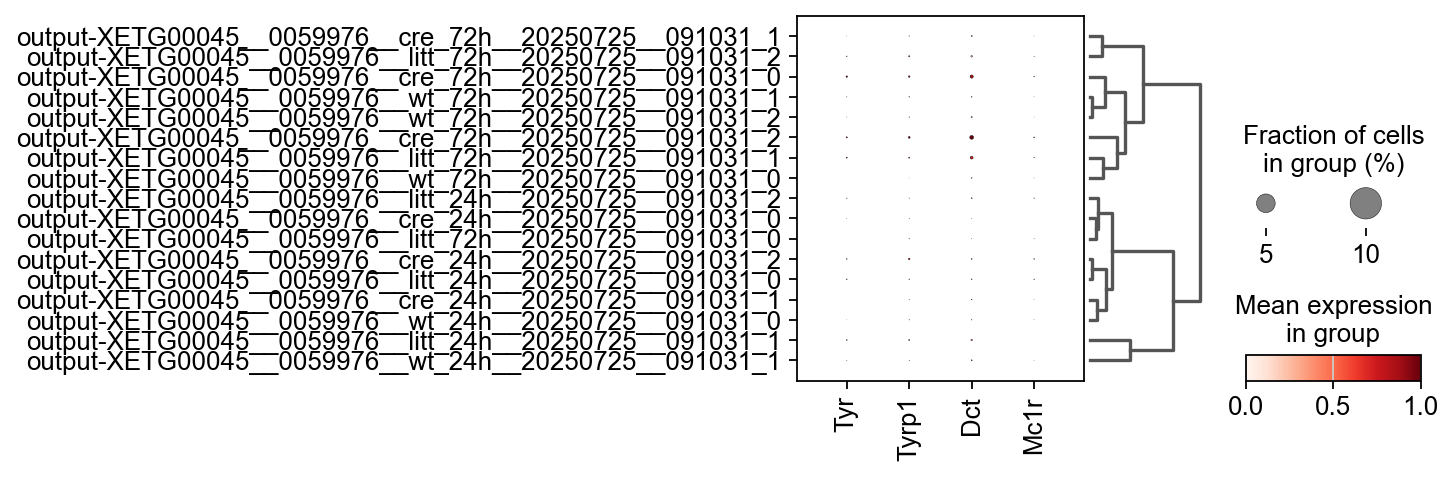

In [30]:
sc.pl.dotplot(
        adata,
        var_names=core_melanin_genes,
        groupby="sample_id",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        dendrogram=True,
        figsize=(5, 3),
        #categories_order=['Ctrl','Early','Peak','Late'],
    )